Accuracy: 0.75

Macro Average
Precision: 0.7936507936507936
Recall: 0.8095238095238096
F1 Score: 0.7444444444444445

Weighted Average
Precision: 0.8273809523809523
Recall: 0.75
F1 Score: 0.7229166666666667

Confusion Matrix
[[4 0 0]
 [2 3 2]
 [0 0 5]]

Classification Report
              precision    recall  f1-score   support

         Low       0.67      1.00      0.80         4
      Medium       1.00      0.43      0.60         7
        High       0.71      1.00      0.83         5

    accuracy                           0.75        16
   macro avg       0.79      0.81      0.74        16
weighted avg       0.83      0.75      0.72        16


Predicted Class: Medium


c:\Users\rajni\ml-lab\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


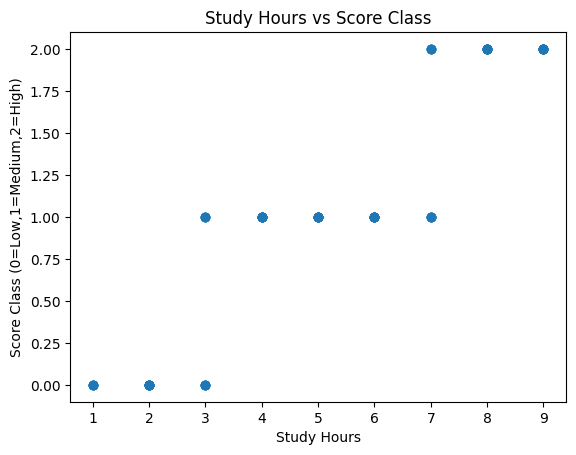

In [5]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report

import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("student_performance.csv")

# Create class labels from Score
# 0 = Low
# 1 = Medium
# 2 = High

score = df["Score"]

conditions = [
    score < 50,
    (score >= 50) & (score < 75),
    score >= 75
]

choices = [0,1,2]

df["ScoreClass"] = np.select(conditions, choices)

# Features and target
X = df[["StudyHours","Attendance","SleepHours"]]
y = df["ScoreClass"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Feature scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# SVM model
svm = SVC(
    kernel="rbf",
    C=1.0,
    gamma="scale",
    decision_function_shape="ovr"
)

svm.fit(X_train_scaled, y_train)

# Predictions
y_pred = svm.predict(X_test_scaled)

# Evaluation metrics
accuracy = accuracy_score(y_test, y_pred)

precision_macro = precision_score(y_test, y_pred, average="macro")
recall_macro = recall_score(y_test, y_pred, average="macro")
f1_macro = f1_score(y_test, y_pred, average="macro")

precision_weighted = precision_score(y_test, y_pred, average="weighted")
recall_weighted = recall_score(y_test, y_pred, average="weighted")
f1_weighted = f1_score(y_test, y_pred, average="weighted")

print("Accuracy:", accuracy)

print("\nMacro Average")
print("Precision:", precision_macro)
print("Recall:", recall_macro)
print("F1 Score:", f1_macro)

print("\nWeighted Average")
print("Precision:", precision_weighted)
print("Recall:", recall_weighted)
print("F1 Score:", f1_weighted)

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report")
print(classification_report(
    y_test,
    y_pred,
    target_names=["Low","Medium","High"]
))

# Predict new sample
# StudyHours = 6
# Attendance = 85
# SleepHours = 7

input_data = [[6,85,7]]

input_scaled = scaler.transform(input_data)

prediction = svm.predict(input_scaled)[0]

labels = ["Low","Medium","High"]

print("\nPredicted Class:", labels[prediction])

# Visualization
plt.scatter(df["StudyHours"], df["ScoreClass"])

plt.xlabel("Study Hours")
plt.ylabel("Score Class (0=Low,1=Medium,2=High)")
plt.title("Study Hours vs Score Class")

plt.show()